In [101]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [102]:
exp_ids_df = pd.read_csv('../scripts/results/per_subject/exp_ids.csv')
all_data_df = pd.read_csv('../scripts/results/per_subject/all_data.csv')

In [103]:
exp_ids_df

,exp_id,cv_subject,unet_performance_statistics_path,method,json_path
0,exp-real-cv-subject-FD-027-2025-08-13T14-05-32,FD-027,/home/miguel/GI/1.5 - Synthetic Data Generatio...,real,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
1,exp-synthetic_subfolder_0-cv-subject-FD-027-20...,FD-027,tmp/all_data.csv,synthetic_subfolder_0,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
2,exp-synthetic_subfolder_1-cv-subject-FD-027-20...,FD-027,tmp/all_data.csv,synthetic_subfolder_1,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
3,exp-synthetic_subfolder_2-cv-subject-FD-027-20...,FD-027,tmp/all_data.csv,synthetic_subfolder_2,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
4,exp-synthetic_subfolder_3-cv-subject-FD-027-20...,FD-027,tmp/all_data.csv,synthetic_subfolder_3,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
...,...,...,...,...,...
205,exp-synthetic_subfolder_0-cv-subject-FD-032-20...,FD-032,tmp/all_data.csv,synthetic_subfolder_0,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
206,exp-synthetic_subfolder_1-cv-subject-FD-032-20...,FD-032,tmp/all_data.csv,synthetic_subfolder_1,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
207,exp-synthetic_subfolder_2-cv-subject-FD-032-20...,FD-032,tmp/all_data.csv,synthetic_subfolder_2,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
208,exp-synthetic_subfolder_3-cv-subject-FD-032-20...,FD-032,tmp/all_data.csv,synthetic_subfolder_3,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...


In [104]:
ranges = []
for k in range(5):
    for i in range(0, 72-16, 8):
        for j in range(6):
            ranges.append((i, i+24))

In [107]:
ranges

[(0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (8, 32),
 (8, 32),
 (8, 32),
 (8, 32),
 (8, 32),
 (8, 32),
 (16, 40),
 (16, 40),
 (16, 40),
 (16, 40),
 (16, 40),
 (16, 40),
 (24, 48),
 (24, 48),
 (24, 48),
 (24, 48),
 (24, 48),
 (24, 48),
 (32, 56),
 (32, 56),
 (32, 56),
 (32, 56),
 (32, 56),
 (32, 56),
 (40, 64),
 (40, 64),
 (40, 64),
 (40, 64),
 (40, 64),
 (40, 64),
 (48, 72),
 (48, 72),
 (48, 72),
 (48, 72),
 (48, 72),
 (48, 72),
 (0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (8, 32),
 (8, 32),
 (8, 32),
 (8, 32),
 (8, 32),
 (8, 32),
 (16, 40),
 (16, 40),
 (16, 40),
 (16, 40),
 (16, 40),
 (16, 40),
 (24, 48),
 (24, 48),
 (24, 48),
 (24, 48),
 (24, 48),
 (24, 48),
 (32, 56),
 (32, 56),
 (32, 56),
 (32, 56),
 (32, 56),
 (32, 56),
 (40, 64),
 (40, 64),
 (40, 64),
 (40, 64),
 (40, 64),
 (40, 64),
 (48, 72),
 (48, 72),
 (48, 72),
 (48, 72),
 (48, 72),
 (48, 72),
 (0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (0, 24),
 (8, 32),
 (8, 32),
 (8, 32),
 (8, 32),


In [108]:
all_data_df['start_range'] = [r[0] for r in ranges]
all_data_df['end_range'] = [r[1] for r in ranges]

In [7]:
# Overall downstream task performance evaluation (Synthetic vs. real)

In [8]:
for subject in ['FD-027', 'FD-029', 'FD-030', 'FD-031', 'FD-032']:
    all_data_df_subject = all_data_df[all_data_df['cv_subject'] == subject]

In [109]:
all_data_df

,best_dice_epoch,best_dice_coefficient,best_train_loss,dice_coefficients,best_train_loss_dice_coefficients,final_dice_coefficient,final_dice_coefficient_std,final_train_loss,train_loss_history,train_dice_coefficient_history,method,cv_subject,exp_id,start_range,end_range
0,16,0.488117,0.032855,"[5.037783523675898e-10, 5.21104714934495e-10, ...","[5.037783523675898e-10, 5.21104714934495e-10, ...",0.458333,0.498261,0.032855,"[1.1596031188964844, 0.8766667065413102, 0.668...","[0.04385240344066284, 0.04398141680344892, 0.0...",real,FD-027,exp-real-cv-subject-FD-027-2025-08-13T14-05-32,0,24
1,23,0.375000,0.076008,"[0.014910537749528885, 0.09811694920063019, 0....","[5.037783523675898e-10, 0.08100000023841858, 0...",0.200730,0.366821,0.076008,"[1.3505742601726367, 1.0178991115611533, 0.802...","[0.04336000635226655, 0.04361522761030575, 0.0...",synthetic_subfolder_0,FD-027,exp-synthetic_subfolder_0-cv-subject-FD-027-20...,0,24
2,21,0.478919,0.032026,"[5.037783523675898e-10, 0.07785888016223907, 5...","[5.037783523675898e-10, 5.21104714934495e-10, ...",0.336577,0.469363,0.032026,"[0.8497022986412048, 0.6612806009209674, 0.521...","[0.0435315776338886, 0.04398359694861768, 0.04...",synthetic_subfolder_1,FD-027,exp-synthetic_subfolder_1-cv-subject-FD-027-20...,0,24
3,28,0.197459,0.039824,"[0.4061485230922699, 0.3962346613407135, 0.346...","[0.48708096146583557, 0.4718683660030365, 0.44...",0.145818,0.152337,0.039824,"[1.0574506806290669, 0.7644324846889662, 0.571...","[0.043623597203824804, 0.043390876112051335, 0...",synthetic_subfolder_2,FD-027,exp-synthetic_subfolder_2-cv-subject-FD-027-20...,0,24
4,22,0.303682,0.024377,"[0.7271756529808044, 0.6862385272979736, 0.663...","[0.7353346347808838, 0.6754896640777588, 0.654...",0.270171,0.281267,0.024377,"[0.520928803993308, 0.39219827496487164, 0.304...","[0.04318341700342572, 0.04372235400782144, 0.0...",synthetic_subfolder_3,FD-027,exp-synthetic_subfolder_3-cv-subject-FD-027-20...,0,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,8,0.083333,0.037745,"[1.0, 1.0, 2.4752475624723047e-09, 1.455604081...","[1.0, 1.0, 2.4752475624723047e-09, 1.455604081...",0.083333,0.276385,0.039374,"[0.9685170469076737, 0.7478450977283976, 0.608...","[0.031402727960409126, 0.031005149633181833, 0...",synthetic_subfolder_0,FD-032,exp-synthetic_subfolder_0-cv-subject-FD-032-20...,48,72
206,24,0.160438,0.033753,"[1.802776261605743e-10, 1.6586498841064667e-10...","[1.6952025894134692e-10, 1.2843565100340015e-1...",0.082905,0.122383,0.038382,"[0.9534990243289782, 0.7504394002582716, 0.597...","[0.03164860902486058, 0.030855446048594325, 0....",synthetic_subfolder_1,FD-032,exp-synthetic_subfolder_1-cv-subject-FD-032-20...,48,72
207,28,0.248827,0.021780,"[2.7777778299764577e-08, 1.872659138868471e-09...","[1.0, 2.257336317867953e-09, 1.443001385048603...",0.213254,0.256116,0.021780,"[0.613011448279671, 0.45875234318816144, 0.354...","[0.03156307696706282, 0.031280457778074096, 0....",synthetic_subfolder_2,FD-032,exp-synthetic_subfolder_2-cv-subject-FD-032-20...,48,72
208,10,0.083333,0.064695,"[1.0, 1.0, 2.4752475624723047e-09, 1.455604081...","[1.0, 1.0, 2.4752475624723047e-09, 1.455604081...",0.083333,0.276385,0.064695,"[1.4097190162409907, 1.0397770352985547, 0.784...","[0.031106581877948555, 0.031335202012216616, 0...",synthetic_subfolder_3,FD-032,exp-synthetic_subfolder_3-cv-subject-FD-032-20...,48,72


[INFO] Per-subject summary using metric='best_dice_coefficient':


,cv_subject,real_mean,synth_mean,gap_mean,real_median,synth_median,gap_median,real_std,synth_std,real_n,synth_n
0,FD-027,0.369779,0.307389,-0.062389,0.325466,0.286761,-0.038705,0.154893,0.219720,7,35
1,FD-029,0.407381,0.438665,0.031284,0.360871,0.443166,0.082295,0.150264,0.151240,7,35
2,FD-030,0.445141,0.416129,-0.029013,0.542156,0.375075,-0.167081,0.219373,0.323888,7,35
3,FD-031,0.437309,0.354384,-0.082925,0.552665,0.387452,-0.165212,0.253831,0.142262,7,35
4,FD-032,0.374072,0.289795,-0.084277,0.328779,0.291667,-0.037113,0.143633,0.155618,7,35


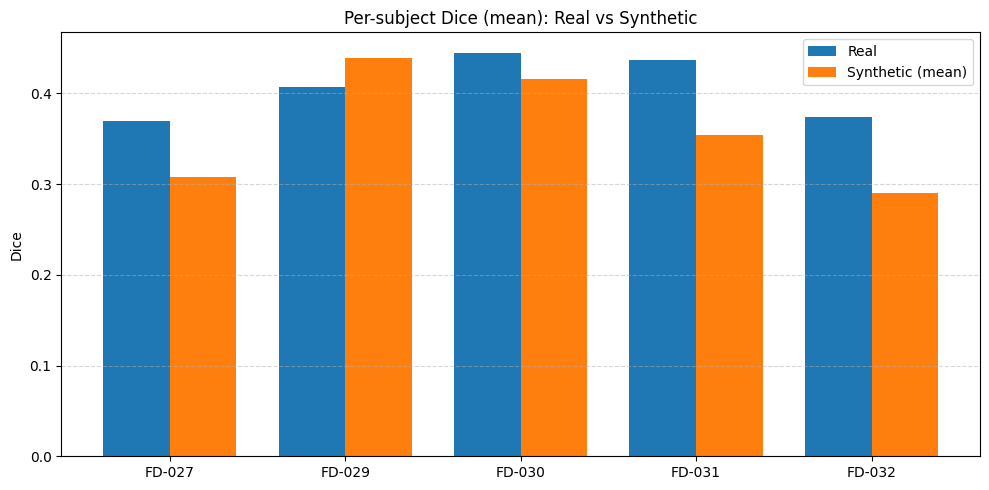

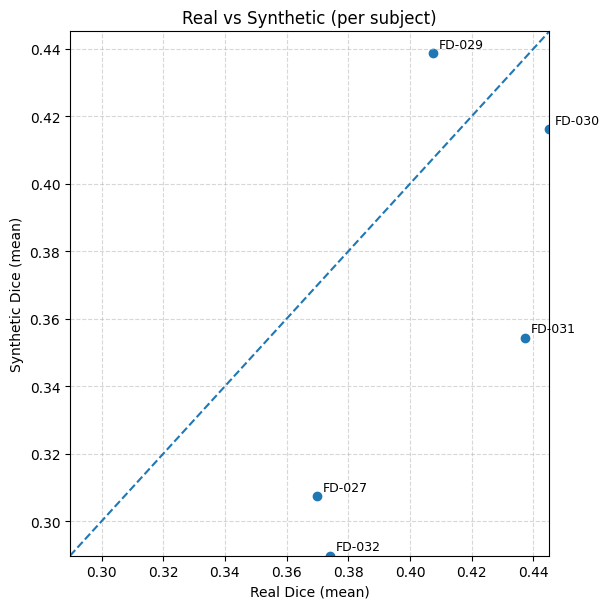

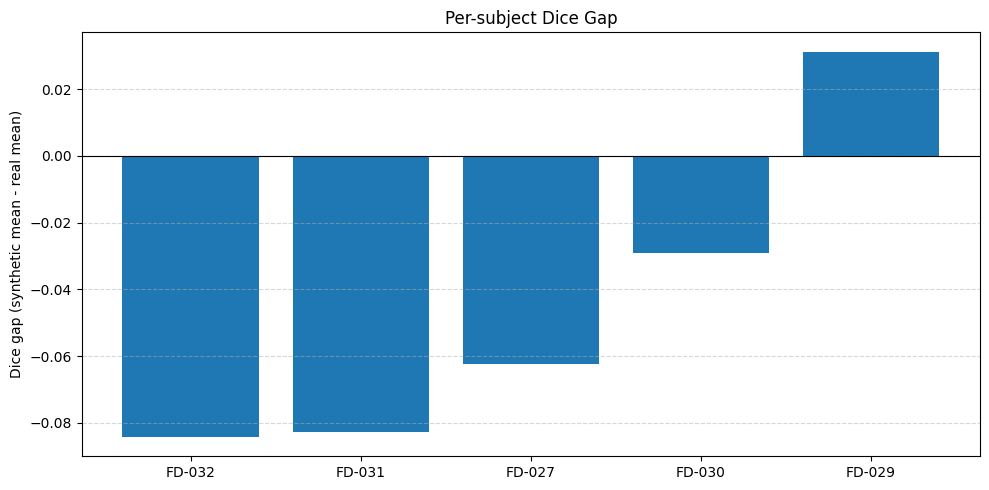

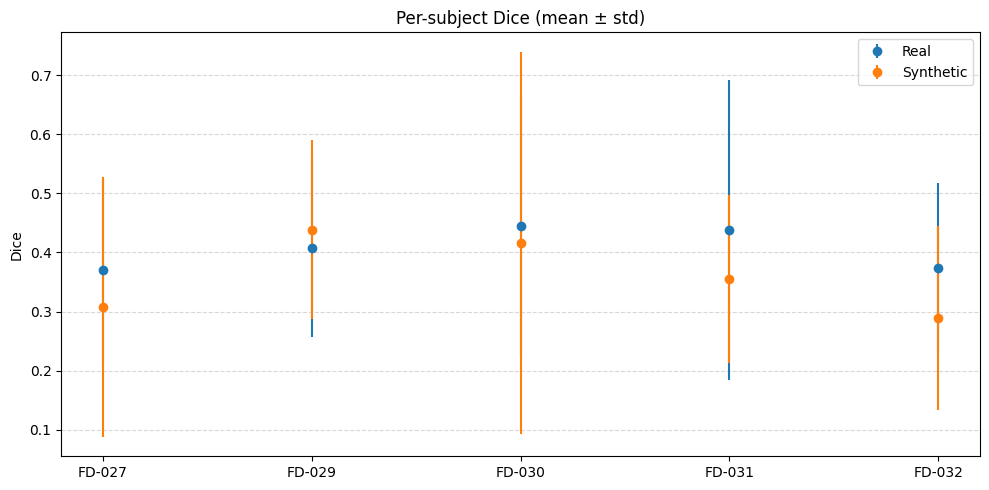

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_subject_level(all_data_df, metric='final_dice_coefficient', save_prefix=None):
    """
    Aggregate all subjects and compare REAL vs SYNTHETIC per subject.
    metric: 'best_dice_coefficient' (default) or 'final_dice_coefficient'
    save_prefix: if set, saves figs as f"{save_prefix}_A.png", etc.
    """

    df = all_data_df.copy()

    # Ensure numeric metric
    df[metric] = pd.to_numeric(df[metric], errors='coerce')

    # Split real vs synthetic
    real = df[df['method'] == 'real']
    synth = df[df['method'] != 'real']

    # Aggregate per subject
    real_subj = (real.groupby('cv_subject')[metric]
                    .agg(real_mean='mean', real_median='median', real_std='std', real_n='count')
                    .reset_index())
    synth_subj = (synth.groupby('cv_subject')[metric]
                     .agg(synth_mean='mean', synth_median='median', synth_std='std', synth_n='count')
                     .reset_index())

    comp = pd.merge(real_subj, synth_subj, on='cv_subject', how='outer').sort_values('cv_subject')
    comp['gap_mean'] = comp['synth_mean'] - comp['real_mean']
    comp['gap_median'] = comp['synth_median'] - comp['real_median']

    # ---- Quick view table
    display_cols = [
        'cv_subject','real_mean','synth_mean','gap_mean',
        'real_median','synth_median','gap_median','real_std','synth_std','real_n','synth_n'
    ]
    print(f"[INFO] Per-subject summary using metric='{metric}':")
    try:
        display(comp[display_cols])
    except Exception:
        print(comp[display_cols].to_string(index=False))

    # ====== A) Grouped bar: Real vs Synthetic mean Dice per subject ======
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(comp))
    width = 0.38
    ax.bar(x - width/2, comp['real_mean'], width, label='Real')
    ax.bar(x + width/2, comp['synth_mean'], width, label='Synthetic (mean)')
    ax.set_xticks(x)
    ax.set_xticklabels(comp['cv_subject'], rotation=0)
    ax.set_ylabel('Dice')
    ax.set_title('Per-subject Dice (mean): Real vs Synthetic')
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_A_grouped_bar.png", dpi=180)
    plt.show()

    # ====== B) Scatter: Real vs Synthetic mean Dice per subject ======
    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    ax.scatter(comp['real_mean'], comp['synth_mean'])
    lims = [
        np.nanmin([comp['real_mean'].values, comp['synth_mean'].values]),
        np.nanmax([comp['real_mean'].values, comp['synth_mean'].values])
    ]
    if np.isfinite(lims).all():
        ax.plot(lims, lims, linestyle='--')  # y = x
        ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Real Dice (mean)')
    ax.set_ylabel('Synthetic Dice (mean)')
    ax.set_title('Real vs Synthetic (per subject)')
    ax.grid(True, linestyle='--', alpha=0.5)
    for i, row in comp.iterrows():
        ax.annotate(row['cv_subject'], (row['real_mean'], row['synth_mean']),
                    xytext=(4,4), textcoords='offset points', fontsize=9)
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_B_scatter.png", dpi=180)
    plt.show()

    # ====== C) Gap bar: synthetic mean - real mean per subject ======
    fig, ax = plt.subplots(figsize=(10, 5))
    sorted_comp = comp.sort_values('gap_mean')
    ax.bar(sorted_comp['cv_subject'], sorted_comp['gap_mean'])
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Dice gap (synthetic mean - real mean)')
    ax.set_title('Per-subject Dice Gap')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_C_gap.png", dpi=180)
    plt.show()

    # ====== D) Error bars: mean ± std for real vs synthetic ======
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(comp))
    ax.errorbar(comp['cv_subject'], comp['real_mean'], yerr=comp['real_std'], fmt='o', label='Real')
    ax.errorbar(comp['cv_subject'], comp['synth_mean'], yerr=comp['synth_std'], fmt='o', label='Synthetic')
    ax.set_ylabel('Dice')
    ax.set_title('Per-subject Dice (mean ± std)')
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_D_errorbars.png", dpi=180)
    plt.show()

    return comp  # handy for downstream tables/exports

# --- Run it (across ALL subjects in all_data_df) ---
comp_subject = plot_subject_level(all_data_df, metric='best_dice_coefficient', save_prefix=None)


[Per-subject summary (medians + key p-values)]


,cv_subject,real_median,synthetic_median,gap_mean,rm_anova_real_vs_synthmean_p,rm_anova_all_levels_p,paired_t_p,tost_equivalent
0,FD-027,0.166667,0.166667,-0.045222,0.186100,0.554334,0.186100,False
1,FD-029,0.283930,0.245049,-0.059264,0.449796,0.126744,0.449796,False
2,FD-030,0.166667,0.250000,-0.012331,0.891852,0.899816,0.891852,False
3,FD-031,0.436441,0.128605,-0.169513,0.247755,0.293408,0.247755,False
4,FD-032,0.206636,0.134879,-0.053634,0.300530,0.411888,0.300530,False


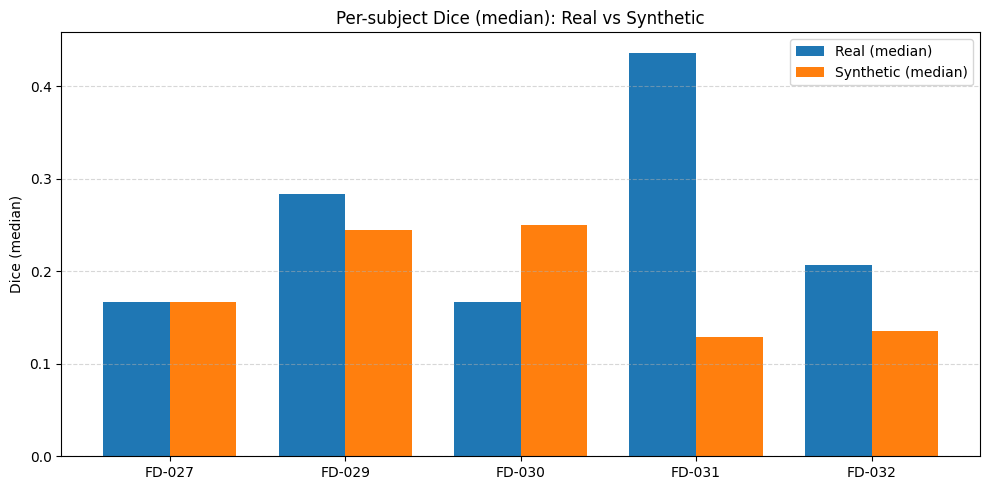

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.anova import AnovaRM

# ------------ helpers ------------

def _block_key(df):
    return df['start_range'].astype(int).astype(str) + '-' + df['end_range'].astype(int).astype(str)

def paired_tost(diff, delta=0.05, alpha=0.05):
    """
    TOST for paired samples via differences array.
    H0: |mu_diff| >= delta   vs   H1: |mu_diff| < delta
    Returns p-values for the two one-sided tests and equivalence boolean.
    """
    diff = np.asarray(diff, dtype=float)
    diff = diff[~np.isnan(diff)]
    n = diff.size
    if n < 2 or np.std(diff, ddof=1) == 0:
        return {"n": int(n), "mean_diff": float(np.nan if n == 0 else diff.mean()),
                "p_lower": np.nan, "p_upper": np.nan, "equivalent": False}
    mean = diff.mean()
    se = diff.std(ddof=1) / np.sqrt(n)
    df = n - 1
    # Test 1: mean_diff > -delta
    t1 = (mean + delta) / se
    p1 = 1 - stats.t.cdf(t1, df=df)
    # Test 2: mean_diff < +delta
    t2 = (mean - delta) / se
    p2 = stats.t.cdf(t2, df=df)
    return {"n": int(n), "mean_diff": float(mean), "p_lower": float(p1), "p_upper": float(p2),
            "equivalent": bool((p1 < alpha) and (p2 < alpha))}

def subject_level_tests(df, metric='best_dice_coefficient', alpha=0.05, delta_equiv=0.05):
    """
    Runs, for each subject:
      - RM-ANOVA on {REAL vs SYNTHETIC-MEAN} across blocks
      - paired t-test REAL vs SYNTHETIC-MEAN
      - paired TOST equivalence REAL vs SYNTHETIC-MEAN (margin = delta_equiv)
      - RM-ANOVA across levels {REAL, synthetic_subfolder_*}
        + pairwise (paired t + TOST) for each subfolder vs REAL
    Returns: summary dict keyed by subject and a compact per-subject table.
    """
    df = df.copy()
    df[metric] = pd.to_numeric(df[metric], errors='coerce')
    df['block'] = _block_key(df)

    out = {}
    rows = []

    subjects = sorted(df['cv_subject'].unique())
    for s in subjects:
        sdf = df[df['cv_subject'] == s].copy()
        real = sdf[sdf['method'] == 'real'].copy()
        synth = sdf[sdf['method'] != 'real'].copy()

        # --- aggregate synthetic per block (mean across subfolders) ---
        real_b = (real.groupby('block')[metric].mean().rename('real').reset_index())
        synth_mean_b = (synth.groupby('block')[metric].mean().rename('synth').reset_index())

        pair = pd.merge(real_b, synth_mean_b, on='block', how='inner').dropna()
        real_vals = pair['real'].values
        synth_vals = pair['synth'].values

        # ---- RM-ANOVA (REAL vs SYNTH-MEAN) ----
        long = pd.concat([
            pair[['block','real']].rename(columns={'real':'dice'}).assign(level='real'),
            pair[['block','synth']].rename(columns={'synth':'dice'}).assign(level='synthetic_mean')
        ], ignore_index=True)
        rm_p = np.nan
        try:
            res = AnovaRM(long, depvar='dice', subject='block', within=['level']).fit()
            rm_p = float(res.anova_table.loc['level','Pr > F'])
        except Exception as e:
            # if blocks unbalanced or too few, ANOVARM may fail; keep NaN
            pass

        # ---- paired t-test & TOST (REAL vs SYNTH-MEAN) ----
        t_p = np.nan
        t_stat = np.nan
        if len(real_vals) >= 2 and len(real_vals) == len(synth_vals):
            t_stat, t_p = stats.ttest_rel(synth_vals, real_vals, nan_policy='omit')
        tost = paired_tost(synth_vals - real_vals, delta=delta_equiv, alpha=alpha)

        # ---- RM-ANOVA across all levels (REAL + each subfolder) ----
        # pivot blocks x levels; drop blocks with any missing level
        sdf['level'] = sdf['method']  # levels include 'real' and 'synthetic_subfolder_X'
        piv = sdf.pivot_table(index='block', columns='level', values=metric, aggfunc='mean')
        piv = piv.dropna(axis=0, how='any')
        rm_all_p = np.nan
        pairwise = {}
        if piv.shape[0] >= 2 and 'real' in piv.columns:
            long_all = piv.reset_index().melt(id_vars='block', var_name='level', value_name='dice')
            try:
                res_all = AnovaRM(long_all, depvar='dice', subject='block', within=['level']).fit()
                rm_all_p = float(res_all.anova_table.loc['level','Pr > F'])
            except Exception:
                pass

            # Pairwise vs REAL (paired t + TOST) for each synthetic subfolder
            for col in piv.columns:
                if col == 'real':
                    continue
                d = piv[col].values - piv['real'].values
                tstat, tp = stats.ttest_rel(piv[col].values, piv['real'].values, nan_policy='omit')
                pairwise[col] = {
                    "mean_gap": float(np.nanmean(d)),
                    "paired_t_p": float(tp),
                    "tost": paired_tost(d, delta=delta_equiv, alpha=alpha)
                }

        # --- subject-level medians for plotting ---
        real_median = real[metric].median()
        synth_median = synth[metric].median()  # median across all synthetic rows (all subfolders)

        out[s] = {
            "n_blocks_paired": int(pair.shape[0]),
            "real_mean": float(np.nanmean(real_vals)) if len(real_vals) else np.nan,
            "synth_mean": float(np.nanmean(synth_vals)) if len(synth_vals) else np.nan,
            "real_median": float(real_median),
            "synth_median": float(synth_median),
            "gap_mean": float((np.nanmean(synth_vals) - np.nanmean(real_vals)) if len(real_vals) and len(synth_vals) else np.nan),
            "rm_anova_real_vs_synthmean_p": rm_p,
            "paired_t_p": float(t_p),
            "paired_t_stat": float(t_stat),
            "tost_equivalence": tost,                 # contains p_lower, p_upper, equivalent
            "rm_anova_all_levels_p": rm_all_p,        # real + each synthetic subfolder
            "pairwise_vs_real": pairwise              # per subfolder stats
        }

        rows.append({
            "cv_subject": s,
            "real_median": out[s]["real_median"],
            "synthetic_median": out[s]["synth_median"],
            "gap_mean": out[s]["gap_mean"],
            "rm_anova_real_vs_synthmean_p": out[s]["rm_anova_real_vs_synthmean_p"],
            "rm_anova_all_levels_p": out[s]["rm_anova_all_levels_p"],
            "paired_t_p": out[s]["paired_t_p"],
            "tost_equivalent": out[s]["tost_equivalence"]["equivalent"]
        })

    table = pd.DataFrame(rows).sort_values('cv_subject')
    return out, table

# ------------ run stats & plot ------------

# choose metric; you can switch to 'final_dice_coefficient' if you prefer
metric = 'final_dice_coefficient'
alpha = 0.05
delta_equiv = 0.05   # equivalence margin in Dice; change to your tolerance

stats_summary, per_subject_table = subject_level_tests(
    all_data_df, metric=metric, alpha=alpha, delta_equiv=delta_equiv
)

print("[Per-subject summary (medians + key p-values)]")
try:
    display(per_subject_table)
except:
    print(per_subject_table.to_string(index=False))

# ---- Bar chart: MEDIANS per subject (as requested) ----
fig, ax = plt.subplots(figsize=(10, 5))
subjects = per_subject_table['cv_subject'].tolist()
x = np.arange(len(subjects))
width = 0.38

real_med = per_subject_table['real_median'].values
syn_med  = per_subject_table['synthetic_median'].values

ax.bar(x - width/2, real_med, width, label='Real (median)')
ax.bar(x + width/2, syn_med,  width, label='Synthetic (median)')

ax.set_xticks(x); ax.set_xticklabels(subjects)
ax.set_ylabel('Dice (median)')
ax.set_title('Per-subject Dice (median): Real vs Synthetic')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.io import read_image
import re

# ---------- 1) Block scoring (same idea as before) ----------

def _ensure_numeric(df, metric):
    out = df.copy()
    out[metric] = pd.to_numeric(out[metric], errors='coerce')
    return out

def build_block_tables(all_data_df, metric='best_dice_coefficient'):
    """
    Returns a dict with:
      - 'agg' : per-block table (real vs. synthetic aggregated over subfolders)
      - 'by_subfolder' : per-block *per-subfolder* table (real repeated per block for convenience)
    """
    df = _ensure_numeric(all_data_df, metric)

    # ----- REAL per block -----
    real_blk = (df[df['method'] == 'real']
                .groupby(['cv_subject', 'start_range', 'end_range'])[metric]
                .agg(real_mean='mean', real_median='median')
                .reset_index())

    # ===== A) Aggregated over subfolders (same as before) =====
    synth_agg = (df[df['method'] != 'real']
                 .groupby(['cv_subject', 'start_range', 'end_range'])[metric]
                 .agg(synth_mean='mean', synth_median='median', synth_std='std', synth_n='count')
                 .reset_index())

    comp_agg = (pd.merge(real_blk, synth_agg,
                         on=['cv_subject', 'start_range', 'end_range'], how='inner')
                .sort_values(['cv_subject', 'start_range', 'end_range']))
    comp_agg['block'] = (comp_agg['start_range'].astype(int).astype(str)
                         + '-' + comp_agg['end_range'].astype(int).astype(str))
    comp_agg['gap_mean'] = comp_agg['synth_mean'] - comp_agg['real_mean']
    comp_agg['gap_median'] = comp_agg['synth_median'] - comp_agg['real_median']

    # ===== B) Per subfolder =====
    # Expect method like: 'synthetic_subfolder_0'  → subfolder='subfolder_0'
    synth = df[df['method'] != 'real'].copy()
    synth['subfolder'] = synth['method'].apply(
        lambda m: re.sub(r'^synthetic_', '', m) if isinstance(m, str) else m
    )

    synth_by_sf = (synth
                   .groupby(['cv_subject', 'start_range', 'end_range', 'subfolder'])[metric]
                   .agg(synth_mean='mean', synth_median='median', synth_std='std', synth_n='count')
                   .reset_index())

    comp_by_sf = (pd.merge(real_blk, synth_by_sf,
                           on=['cv_subject', 'start_range', 'end_range'], how='inner')
                  .sort_values(['cv_subject', 'start_range', 'end_range', 'subfolder']))
    comp_by_sf['block'] = (comp_by_sf['start_range'].astype(int).astype(str)
                           + '-' + comp_by_sf['end_range'].astype(int).astype(str))
    comp_by_sf['gap_mean'] = comp_by_sf['synth_mean'] - comp_by_sf['real_mean']
    comp_by_sf['gap_median'] = comp_by_sf['synth_median'] - comp_by_sf['real_median']

    return {"agg": comp_agg, "by_subfolder": comp_by_sf}



def pick_top_blocks(comp_table, cv_subject, by='synth_median', k=2, descending=True):
    ct = comp_table[comp_table['cv_subject']==cv_subject].dropna(subset=[by]).copy()
    return ct.sort_values(by, ascending=not descending).head(k)

# ---------- 2) IO helpers ----------
def _to_np(img_tensor):
    arr = img_tensor.numpy()
    if arr.ndim == 3:  # C,H,W -> H,W,C
        arr = np.transpose(arr, (1,2,0))
        if arr.shape[2] == 1:
            arr = arr[:,:,0]
    return arr

def list_eval_pairs(block_folder):
    eval_dir = os.path.join(block_folder, 'eval')
    images = sorted(glob.glob(os.path.join(eval_dir, '*image*.png')))
    pairs = []
    for im in images:
        mask = im.replace('image', 'mask')
        if os.path.exists(mask):
            pairs.append((im, mask))
    return pairs

def find_synthetic_siblings(real_img_path, train_synth_root, max_k=2):
    """
    Find up to max_k synthetic images derived from the given real image.
    We search all subfolders under train_synthetic/ whose filenames start with the real basename + '_synthetic_'.
    """
    real_base = os.path.basename(real_img_path).replace('.png','')  # e.g., FD-029-slice-26-image
    patt = os.path.join(train_synth_root, 'subfolder_*', f'{real_base}_synthetic_*.png')
    synth_paths = sorted(glob.glob(patt))
    # Spread picks across subfolders (first from each, round-robin)
    by_sub = {}
    for p in synth_paths:
        sub = os.path.basename(os.path.dirname(p))  # subfolder_X
        by_sub.setdefault(sub, []).append(p)
    # round-robin
    chosen, q = [], list(by_sub.items())
    idx = {s:0 for s,_ in q}
    while len(chosen) < max_k and q:
        for s, files in q:
            if idx[s] < len(files):
                chosen.append(files[idx[s]])
                idx[s] += 1
                if len(chosen) >= max_k: break
        # stop if every list is exhausted
        if all(idx[s] >= len(files) for s,files in q): break
    return chosen

# ---------- 3) Plotting ----------
def plot_contour(ax, mask_np, color='r', lw=1.0):
    # plot a clean contour at level ~0.5
    ax.contour((mask_np > 0).astype(float), levels=[0.5], colors=[color], linewidths=lw)

def plot_block_with_synthetics(per_subject_root, cv_subject, block_name, n_pairs=6, k_synth=2,
                               by_text=None, scores=None):
    """
    Make a figure for one block with rows of images:
      [Real] | [Real + contour] | [Synth #1] | [Synth #2] | ...
    """
    block_folder = os.path.join(per_subject_root, cv_subject, block_name)
    eval_pairs = list_eval_pairs(block_folder)
    if not eval_pairs:
        print(f"[WARN] No eval pairs in {block_folder}")
        return

    train_synth_root = os.path.join(block_folder, 'train_synthetic')
    cols = 2 + k_synth
    rows = min(n_pairs, len(eval_pairs))
    sel_idx = np.linspace(0, len(eval_pairs)-1, num=rows, dtype=int)
    sel = [eval_pairs[i] for i in sel_idx]

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.8, rows*3.3))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, (img_path, mask_path) in enumerate(sel):
        img = _to_np(read_image(img_path))
        msk = _to_np(read_image(mask_path))
        msk_bin = (msk > 0).astype(np.uint8)

        # Real
        ax0 = axes[r, 0]
        ax0.imshow(img, cmap='gray'); ax0.axis('off')
        if r == 0: ax0.set_title('Real')

        # Real + contour
        ax1 = axes[r, 1]
        ax1.imshow(img, cmap='gray'); plot_contour(ax1, msk_bin, color='r', lw=1.1)
        ax1.axis('off')
        if r == 0: ax1.set_title('Real + mask contour')

        # Synthetic siblings
        synths = find_synthetic_siblings(img_path, train_synth_root, max_k=k_synth)
        for c, spath in enumerate(synths, start=2):
            s_img = _to_np(read_image(spath))
            ax = axes[r, c]
            ax.imshow(s_img, cmap='gray')
            # (masks for synthetic == real mask in your pipeline; draw contour for reference)
            plot_contour(ax, msk_bin, color='r', lw=1.0)
            ax.axis('off')
            if r == 0:
                sub = os.path.basename(os.path.dirname(spath))  # subfolder_X
                sid = os.path.basename(spath).split('_synthetic_')[-1].replace('.png','')
                ax.set_title(f"Synthetic\n{sub} / id={sid}", fontsize=9)

        # if fewer than k_synth found, blank the remaining cells
        for c in range(2 + len(synths), cols):
            axes[r, c].axis('off')

    title_bits = [f"{cv_subject} — {block_name}"]
    if by_text: title_bits.append(by_text)
    if isinstance(scores, dict):
        # e.g., scores={'real_med':0.44,'synth_med':0.41,'gap':-0.03}
        meta = ", ".join([f"{k}={v:.3f}" for k,v in scores.items() if v is not None and np.isfinite(v)])
        if meta: title_bits.append(meta)
    fig.suptitle(" | ".join(title_bits), y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

# ---------- 4) From scores to figures ----------
def show_best_blocks_with_synthetics(
    all_data_df,
    per_subject_root,
    cv_subject,
    by='synth_median',  # or 'gap_median', 'real_median'
    k_blocks=2,
    n_pairs=6,
    k_synth=2
):
    comp = build_block_table(all_data_df, metric='best_dice_coefficient')
    topb = pick_top_blocks(comp, cv_subject=cv_subject, by=by, k=k_blocks, descending=True)
    if topb.empty:
        print(f"[WARN] No top blocks for {cv_subject} by '{by}'.")
        return
    for _, row in topb.iterrows():
        # Your block folders look like "block_0_0_to_24"
        block_name = f"block_{int(row['start_range']/8)}_{int(row['start_range'])}_to_{int(row['end_range'])}"
        scores = dict(real_med=row.get('real_median', np.nan),
                      synth_med=row.get('synth_median', np.nan),
                      gap=row.get('gap_median', np.nan))
        by_text = f"sorted by {by}"
        plot_block_with_synthetics(per_subject_root, cv_subject, block_name,
                                   n_pairs=n_pairs, k_synth=k_synth,
                                   by_text=by_text, scores=scores)


In [12]:
PER_SUBJECT_FOLDER = '/home/miguel/GI/1.5 - Synthetic Data Generation/experiments/synthetic-data-training-benchmark/singan/data/per-subject'

In [112]:
all_data_df[['start_range', 'end_range']].values.tolist()

[[0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [8, 32],
 [8, 32],
 [8, 32],
 [8, 32],
 [8, 32],
 [8, 32],
 [16, 40],
 [16, 40],
 [16, 40],
 [16, 40],
 [16, 40],
 [16, 40],
 [24, 48],
 [24, 48],
 [24, 48],
 [24, 48],
 [24, 48],
 [24, 48],
 [32, 56],
 [32, 56],
 [32, 56],
 [32, 56],
 [32, 56],
 [32, 56],
 [40, 64],
 [40, 64],
 [40, 64],
 [40, 64],
 [40, 64],
 [40, 64],
 [48, 72],
 [48, 72],
 [48, 72],
 [48, 72],
 [48, 72],
 [48, 72],
 [0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [8, 32],
 [8, 32],
 [8, 32],
 [8, 32],
 [8, 32],
 [8, 32],
 [16, 40],
 [16, 40],
 [16, 40],
 [16, 40],
 [16, 40],
 [16, 40],
 [24, 48],
 [24, 48],
 [24, 48],
 [24, 48],
 [24, 48],
 [24, 48],
 [32, 56],
 [32, 56],
 [32, 56],
 [32, 56],
 [32, 56],
 [32, 56],
 [40, 64],
 [40, 64],
 [40, 64],
 [40, 64],
 [40, 64],
 [40, 64],
 [48, 72],
 [48, 72],
 [48, 72],
 [48, 72],
 [48, 72],
 [48, 72],
 [0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [0, 24],
 [8, 32],
 [8, 32],
 [8, 32],
 [8, 32],


In [13]:
all_data_df = all_data_df.reset_index()

In [14]:
real_dfs = all_data_df[all_data_df['method'] == 'real']
synthetic_dfs = all_data_df[all_data_df['method'] != 'real']

In [87]:
real_data_row['exp_id']

'exp-real-cv-subject-FD-027-2025-08-13T14-05-32'

In [ ]:
performance_datas = []

for i in synthetic_dfs.index:
    synthetic_row = synthetic_dfs.loc[i]
    close_rows = real_dfs[(real_dfs['start_range'] == synthetic_row['start_range']) & (real_dfs['end_range'] == synthetic_row['end_range'])]
    close_rows = close_rows[close_rows['index'] < synthetic_row['index']]
    real_data_row = close_rows.loc[close_rows.index[-1]]
    performance_datas.append({
        'real_final_dice_coefficient': real_data_row['final_dice_coefficient'],
        'synthetic_dice_coefficient': synthetic_row['final_dice_coefficient'],
        'real_exp_id': real_data_row['exp_id'],
        'synthetic_exp_id': synthetic_row['exp_id'],
        'cv_subject': synthetic_row['cv_subject'],
        'subfolder': synthetic_row['method'],
        'start_range': synthetic_row['start_range'],
        'end_range': synthetic_row['end_range']
    })

In [16]:
performance_datas_df = pd.DataFrame(performance_datas)

In [17]:
performance_datas_df['difference'] = performance_datas_df['synthetic_dice_coefficient'] - performance_datas_df['real_final_dice_coefficient'] 

In [18]:
performance_datas_df = performance_datas_df.sort_values(by = 'difference', ascending = False)

In [19]:
best_performance_datas_df = performance_datas_df.head()
worst_performance_datas_df = performance_datas_df.tail()

In [20]:
import os
from datetime import datetime
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [21]:

# single-level nesting: one timestamped folder with all exports
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = f"comparisons_{ts}"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
UNET_LOGS_PATH = '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs'

In [ ]:
# IT CORRESPONDS TO EACH BLOCK
# RANGE CORRESPONDS TO EACH BLOCK


In [86]:
performance_datas_df

,real_final_dice_coefficient,synthetic_dice_coefficient,real_exp_id,synthetic_exp_id,cv_subject,subfolder,start_range,end_range,difference
95,1.666667e-01,1.000000e+00,exp-real-cv-subject-FD-030-2025-08-13T14-52-18,exp-synthetic_subfolder_0-cv-subject-FD-030-20...,FD-030,synthetic_subfolder_0,40,64,0.833333
98,1.666667e-01,8.750000e-01,exp-real-cv-subject-FD-030-2025-08-13T14-52-18,exp-synthetic_subfolder_3-cv-subject-FD-030-20...,FD-030,synthetic_subfolder_3,40,64,0.708333
107,5.057690e-03,5.410098e-01,exp-real-cv-subject-FD-031-2025-08-13T14-57-14,exp-synthetic_subfolder_2-cv-subject-FD-031-20...,FD-031,synthetic_subfolder_2,0,24,0.535952
50,2.384535e-10,4.974968e-01,exp-real-cv-subject-FD-029-2025-08-13T14-30-08,exp-synthetic_subfolder_0-cv-subject-FD-029-20...,FD-029,synthetic_subfolder_0,24,48,0.497497
109,5.057690e-03,4.469002e-01,exp-real-cv-subject-FD-031-2025-08-13T14-57-14,exp-synthetic_subfolder_4-cv-subject-FD-031-20...,FD-031,synthetic_subfolder_4,0,24,0.441842
...,...,...,...,...,...,...,...,...,...
123,6.502285e-01,3.509205e-02,exp-real-cv-subject-FD-031-2025-08-13T15-04-37,exp-synthetic_subfolder_3-cv-subject-FD-031-20...,FD-031,synthetic_subfolder_3,24,48,-0.615136
122,6.502285e-01,3.827574e-10,exp-real-cv-subject-FD-031-2025-08-13T15-04-37,exp-synthetic_subfolder_2-cv-subject-FD-031-20...,FD-031,synthetic_subfolder_2,24,48,-0.650228
120,6.502285e-01,3.827574e-10,exp-real-cv-subject-FD-031-2025-08-13T15-04-37,exp-synthetic_subfolder_0-cv-subject-FD-031-20...,FD-031,synthetic_subfolder_0,24,48,-0.650228
124,6.502285e-01,3.827574e-10,exp-real-cv-subject-FD-031-2025-08-13T15-04-37,exp-synthetic_subfolder_4-cv-subject-FD-031-20...,FD-031,synthetic_subfolder_4,24,48,-0.650228


In [100]:
for i in best_performance_datas_df.index:
    row = best_performance_datas_df.loc[i]

    real_pred_folder  = os.path.join(UNET_LOGS_PATH, row['real_exp_id'],      'fold_1', 'predictions')
    synth_pred_folder = os.path.join(UNET_LOGS_PATH, row['synthetic_exp_id'], 'fold_1', 'predictions')

    subj     = row['cv_subject']
    to_range = f"{row['start_range']}_to_{row['end_range']}"


    cv_path   = os.path.join(PER_SUBJECT_FOLDER, subj)
    block     = [f for f in os.listdir(cv_path) if to_range in f][0]
    eval_dir  = os.path.join(cv_path, block, 'eval')

    sorted_real_preds = sorted(os.listdir(real_pred_folder))
    sorted_synth_preds = sorted(os.listdir(synth_pred_folder))

    print("Real Predictions:", sorted_real_preds)
    print("Synthetic Predictions:", sorted_synth_preds)
    print('Evaluation Directory:', eval_dir)
    print('\n')

Real Predictions: ['FD-030-slice-01-original_image.png', 'FD-030-slice-01-original_mask.png', 'FD-030-slice-01-predicted.png', 'FD-030-slice-02-original_image.png', 'FD-030-slice-02-original_mask.png', 'FD-030-slice-02-predicted.png', 'FD-030-slice-03-original_image.png', 'FD-030-slice-03-original_mask.png', 'FD-030-slice-03-predicted.png', 'FD-030-slice-04-original_image.png', 'FD-030-slice-04-original_mask.png', 'FD-030-slice-04-predicted.png', 'FD-030-slice-05-original_image.png', 'FD-030-slice-05-original_mask.png', 'FD-030-slice-05-predicted.png', 'FD-030-slice-06-original_image.png', 'FD-030-slice-06-original_mask.png', 'FD-030-slice-06-predicted.png', 'FD-030-slice-07-original_image.png', 'FD-030-slice-07-original_mask.png', 'FD-030-slice-07-predicted.png', 'FD-030-slice-08-original_image.png', 'FD-030-slice-08-original_mask.png', 'FD-030-slice-08-predicted.png', 'FD-030-slice-09-original_image.png', 'FD-030-slice-09-original_mask.png', 'FD-030-slice-09-predicted.png', 'FD-030-s

In [95]:
os.listdir()

TypeError: listdir: path should be string, bytes, os.PathLike, integer or None, not list

Skipping: FD-030-slice-41-image.png
Skipping: FD-030-slice-42-image.png
Skipping: FD-030-slice-43-image.png
Skipping: FD-030-slice-44-image.png
Skipping: FD-030-slice-45-image.png
Skipping: FD-030-slice-46-image.png
Skipping: FD-030-slice-47-image.png
Skipping: FD-030-slice-48-image.png
Skipping: FD-030-slice-49-image.png
Skipping: FD-030-slice-50-image.png
Skipping: FD-030-slice-51-image.png
Skipping: FD-030-slice-52-image.png
Skipping: FD-030-slice-53-image.png
Skipping: FD-030-slice-54-image.png
Skipping: FD-030-slice-55-image.png
Skipping: FD-030-slice-56-image.png
Skipping: FD-030-slice-57-image.png
Skipping: FD-030-slice-58-image.png
Skipping: FD-030-slice-59-image.png
Skipping: FD-030-slice-60-image.png
Skipping: FD-030-slice-61-image.png
Skipping: FD-030-slice-62-image.png
Skipping: FD-030-slice-63-image.png
Skipping: FD-030-slice-64-image.png


KeyboardInterrupt: 

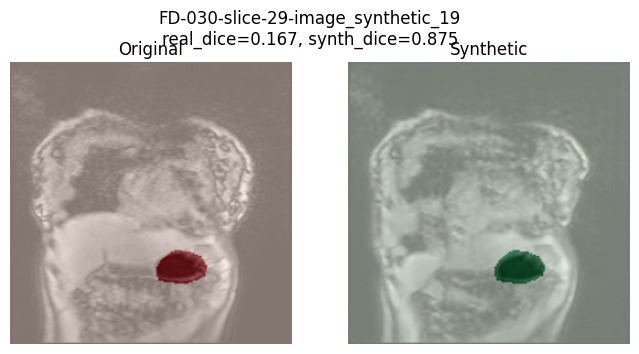

In [98]:
import os
from datetime import datetime
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# two DataFrames to process
dfs = {
    "best": best_performance_datas_df,
    "worst": worst_performance_datas_df
}

# timestamped root
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT = f"comparisons_{ts}"
os.makedirs(OUT_ROOT, exist_ok=True)

def make_overlay(img_p, mask_p, cmap):
    img  = Image.open(img_p).convert("RGB").resize((256,256), Image.BILINEAR)
    mask = Image.open(mask_p).convert("L")   .resize((256,256), Image.NEAREST)
    arr_img  = np.array(img)
    arr_mask = np.array(mask)
    colored  = plt.get_cmap(cmap)(arr_mask/255.0)[..., :3] * 255
    overlay  = (arr_img * 0.5 + colored * 0.5).astype(np.uint8)
    return overlay

for label, df in dfs.items():
    # sub-root for this DF
    df_root = os.path.join(OUT_ROOT, label)
    os.makedirs(df_root, exist_ok=True)

    for i in df.index:
        row      = df.loc[i]
        subj     = row['cv_subject']
        to_range = f"{row['start_range']}_to_{row['end_range']}"
        subfld   = row['subfolder'].replace('synthetic_', '')

        # grab your dice metrics
        real_dice  = row['real_final_dice_coefficient']
        synth_dice = row['synthetic_dice_coefficient']

        cv_path   = os.path.join(PER_SUBJECT_FOLDER, subj)
        block     = [f for f in os.listdir(cv_path) if to_range in f][0]
        real_dir  = os.path.join(cv_path, block, 'train_real')
        synth_dir = os.path.join(cv_path, block, 'train_synthetic', subfld)
        eval_dir  = os.path.join(cv_path, block, 'eval')

        # make one folder per subfolder under best/worst
        train_out = os.path.join(df_root, subfld)
        eval_out  = os.path.join(df_root, subfld + "_eval")
        os.makedirs(train_out, exist_ok=True)
        os.makedirs(eval_out,  exist_ok=True)

        # TRAIN: original vs synthetic
        for fn in os.listdir(synth_dir):
            if 'synthetic' not in fn or 'image' not in fn:
                continue

            base     = fn[:-4]  # strip .png
            title    = f"{base}\nreal_dice={real_dice:.3f}, synth_dice={synth_dice:.3f}"

            syn_p    = os.path.join(synth_dir, fn)
            mask_p   = syn_p.replace('image', 'mask')
            orig_p   = os.path.join(real_dir, fn.split('_synthetic')[0] + '.png')
            o_mask_p = orig_p.replace('image', 'mask')

            orig_ov  = make_overlay(orig_p,  o_mask_p, cmap='Reds')
            synth_ov = make_overlay(syn_p,   mask_p,  cmap='Greens')

            fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,4))
            fig.suptitle(title, fontsize=12)
            ax1.imshow(orig_ov);  ax1.set_title("Original");  ax1.axis('off')
            ax2.imshow(synth_ov); ax2.set_title("Synthetic"); ax2.axis('off')

            out_p = os.path.join(train_out, f"{base}_comparison.png")
            fig.savefig(out_p, bbox_inches='tight')
            plt.close(fig)

        # EVAL + PRED OVERLAYS
        real_pred_folder  = os.path.join(UNET_LOGS_PATH, row['real_exp_id'],      'fold_1', 'predictions')
        synth_pred_folder = os.path.join(UNET_LOGS_PATH, row['synthetic_exp_id'], 'fold_1', 'predictions')

        for fn in sorted(os.listdir(eval_dir)):
            if not fn.endswith('.png') or 'image' not in fn:
                continue

            base      = fn[:-4]
            title     = f"{base}\nreal_dice={real_dice:.3f}, synth_dice={synth_dice:.3f}"

            # input image + GT mask
            img_p     = os.path.join(eval_dir, fn)
            gt_mask_p = img_p.replace('image', 'mask')

            # predicted masks
            real_mask_p  = os.path.join(real_pred_folder,  base.replace('-image', '') + '-predicted.png')
            synth_mask_p = os.path.join(synth_pred_folder, base.replace('-image', '') + '-predicted.png')

            # skip if any file missing
            if not (os.path.exists(gt_mask_p) and
                    os.path.exists(real_mask_p) and
                    os.path.exists(synth_mask_p)):
                print('Skipping:', fn)
                continue
            print('Not skipping')

            # make overlays
            gt_ov    = make_overlay(img_p, gt_mask_p,    cmap='Blues')
            real_ov  = make_overlay(img_p, real_mask_p,  cmap='Purples')
            synth_ov = make_overlay(img_p, synth_mask_p, cmap='Oranges')

            # plot 3 panels
            fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 4))
            fig.suptitle(title, fontsize=12)

            ax0.imshow(gt_ov)
            ax0.set_title("Ground Truth")
            ax0.axis('off')

            ax1.imshow(real_ov)
            ax1.set_title("Real-trained Prediction")
            ax1.axis('off')

            ax2.imshow(synth_ov)
            ax2.set_title("Synthetic-trained Prediction")
            ax2.axis('off')

            # save
            out_eval = os.path.join(eval_out, f"{base}_eval.png")
            fig.savefig(out_eval, bbox_inches='tight')
            plt.close(fig)

            # remove these breaks once you’re happy that it runs on one slice

In [77]:
block

'block_5_40_to_64'

In [88]:
eval_dir + '/' + os.listdir(eval_dir)[0]

'/home/miguel/GI/1.5 - Synthetic Data Generation/experiments/synthetic-data-training-benchmark/singan/data/per-subject/FD-030/block_5_40_to_64/eval/FD-030-slice-53-mask.png'

In [90]:
sorted(os.listdir(synth_pred_folder))

['FD-030-slice-01-original_image.png',
 'FD-030-slice-01-original_mask.png',
 'FD-030-slice-01-predicted.png',
 'FD-030-slice-02-original_image.png',
 'FD-030-slice-02-original_mask.png',
 'FD-030-slice-02-predicted.png',
 'FD-030-slice-03-original_image.png',
 'FD-030-slice-03-original_mask.png',
 'FD-030-slice-03-predicted.png',
 'FD-030-slice-04-original_image.png',
 'FD-030-slice-04-original_mask.png',
 'FD-030-slice-04-predicted.png',
 'FD-030-slice-05-original_image.png',
 'FD-030-slice-05-original_mask.png',
 'FD-030-slice-05-predicted.png',
 'FD-030-slice-06-original_image.png',
 'FD-030-slice-06-original_mask.png',
 'FD-030-slice-06-predicted.png',
 'FD-030-slice-07-original_image.png',
 'FD-030-slice-07-original_mask.png',
 'FD-030-slice-07-predicted.png',
 'FD-030-slice-08-original_image.png',
 'FD-030-slice-08-original_mask.png',
 'FD-030-slice-08-predicted.png',
 'FD-030-slice-09-original_image.png',
 'FD-030-slice-09-original_mask.png',
 'FD-030-slice-09-predicted.png',
 

In [113]:
row['real_exp_id']

'exp-real-cv-subject-FD-031-2025-08-13T14-57-14'

In [115]:
real_exp_folder = os.path.join(UNET_LOGS_PATH, row['real_exp_id'], 'fold_1', 'predictions')
synth_pred_folder = os.path.join(UNET_LOGS_PATH, row['synthetic_exp_id'])

In [116]:
sorted([os.path.join(real_exp_folder, file) for file in os.listdir(real_exp_folder) if 'predicted' in file])

['/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/exp-real-cv-subject-FD-031-2025-08-13T14-57-14/fold_1/predictions/FD-031-slice-41-predicted.png',
 '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/exp-real-cv-subject-FD-031-2025-08-13T14-57-14/fold_1/predictions/FD-031-slice-42-predicted.png',
 '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/exp-real-cv-subject-FD-031-2025-08-13T14-57-14/fold_1/predictions/FD-031-slice-43-predicted.png',
 '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/exp-real-cv-subject-FD-031-2025-08-13T14-57-14/fold_1/predictions/FD-031-slice-44-predicted.png',
 '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/exp-real-cv-subject-FD-031-2025-08-13T14-57-14/fold_1/predictions/FD-031-slice-45-predicted.png',
 '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/exp-real-cv-subject-FD-031-2025-08-13T14-57-14/fold_1/predictions/FD-031-slice

In [69]:
sorted([os.path.join(eval_dir, file) for file in os.listdir(eval_dir) if 'image' in file])

['/home/miguel/GI/1.5 - Synthetic Data Generation/experiments/synthetic-data-training-benchmark/singan/data/per-subject/FD-030/block_5_40_to_64/eval/FD-030-slice-41-image.png',
 '/home/miguel/GI/1.5 - Synthetic Data Generation/experiments/synthetic-data-training-benchmark/singan/data/per-subject/FD-030/block_5_40_to_64/eval/FD-030-slice-42-image.png',
 '/home/miguel/GI/1.5 - Synthetic Data Generation/experiments/synthetic-data-training-benchmark/singan/data/per-subject/FD-030/block_5_40_to_64/eval/FD-030-slice-43-image.png',
 '/home/miguel/GI/1.5 - Synthetic Data Generation/experiments/synthetic-data-training-benchmark/singan/data/per-subject/FD-030/block_5_40_to_64/eval/FD-030-slice-44-image.png',
 '/home/miguel/GI/1.5 - Synthetic Data Generation/experiments/synthetic-data-training-benchmark/singan/data/per-subject/FD-030/block_5_40_to_64/eval/FD-030-slice-45-image.png',
 '/home/miguel/GI/1.5 - Synthetic Data Generation/experiments/synthetic-data-training-benchmark/singan/data/per-sub

In [41]:
row['real_exp_id']

'exp-real-cv-subject-FD-030-2025-08-13T14-52-18'

In [38]:
row['real_exp_id']

'exp-real-cv-subject-FD-030-2025-08-13T14-52-18'

In [ ]:
synthetic_predictions_exp_folder = os.path.join(UNET_LOGS_PATH, row['synthetic_exp_id'], 'fold_1', 'predictions')

In [42]:
synthetic_mask_p

NameError: name 'synthetic_mask_p' is not defined

In [ ]:
exp_folder = os.path.join(UNET_LOGS_PATH, row['real_exp_id'], 'fold_1')

In [ ]:
predictions_folder = os.path.join(exp_folder, 'predictions')

In [ ]:
os.listdir(predictions_folder)

['FD-029-slice-38-original_mask.png',
 'FD-029-slice-48-original_image.png',
 'FD-029-slice-47-original_image.png',
 'FD-029-slice-34-original_mask.png',
 'FD-029-slice-45-original_image.png',
 'FD-029-slice-45-predicted.png',
 'FD-029-slice-40-predicted.png',
 'FD-029-slice-42-predicted.png',
 'FD-029-slice-38-predicted.png',
 'FD-029-slice-30-original_image.png',
 'FD-029-slice-36-predicted.png',
 'FD-029-slice-39-original_mask.png',
 'FD-029-slice-28-predicted.png',
 'FD-029-slice-29-original_image.png',
 'FD-029-slice-48-original_mask.png',
 'FD-029-slice-41-original_image.png',
 'FD-029-slice-37-original_image.png',
 'FD-029-slice-33-original_mask.png',
 'FD-029-slice-43-original_image.png',
 'FD-029-slice-27-original_image.png',
 'FD-029-slice-33-predicted.png',
 'FD-029-slice-48-predicted.png',
 'FD-029-slice-40-original_mask.png',
 'FD-029-slice-29-original_mask.png',
 'FD-029-slice-43-original_mask.png',
 'FD-029-slice-42-original_mask.png',
 'FD-029-slice-25-original_image.pn

In [ ]:
comp_blocks = build_block_tables(all_data_df, metric='best_dice_coefficient')['by_subfolder']

In [ ]:
best_comp_blocks = comp_blocks.sort_values(by='gap_median', ascending = False).head()

In [ ]:
best_comp_blocks = best_comp_blocks.sort_values(by = 'start_range')

In [ ]:
comp_blocks

,cv_subject,start_range,end_range,real_mean,real_median,subfolder,synth_mean,synth_median,synth_std,synth_n,block,gap_mean,gap_median
0,FD-027,0,24,0.488117,0.488117,subfolder_0,0.375000,0.375000,NaN,1,0-24,-0.113117,-0.113117
1,FD-027,0,24,0.488117,0.488117,subfolder_1,0.478919,0.478919,NaN,1,0-24,-0.009198,-0.009198
2,FD-027,0,24,0.488117,0.488117,subfolder_2,0.197459,0.197459,NaN,1,0-24,-0.290658,-0.290658
3,FD-027,0,24,0.488117,0.488117,subfolder_3,0.303682,0.303682,NaN,1,0-24,-0.184435,-0.184435
4,FD-027,0,24,0.488117,0.488117,subfolder_4,0.468142,0.468142,NaN,1,0-24,-0.019975,-0.019975
...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,FD-032,48,72,0.291579,0.291579,subfolder_0,0.083333,0.083333,NaN,1,48-72,-0.208245,-0.208245
171,FD-032,48,72,0.291579,0.291579,subfolder_1,0.160438,0.160438,NaN,1,48-72,-0.131141,-0.131141
172,FD-032,48,72,0.291579,0.291579,subfolder_2,0.248827,0.248827,NaN,1,48-72,-0.042752,-0.042752
173,FD-032,48,72,0.291579,0.291579,subfolder_3,0.083333,0.083333,NaN,1,48-72,-0.208245,-0.208245
